In [1]:
import torch
from torch import nn
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import PIL
from PIL import Image
import numpy as np
import os

In [2]:
path = "C:\\Users\\pro\\Documents\\GitHub\\doodle\\train\\data"
list_npy = os.listdir(path)
list_npy

['.ipynb_checkpoints',
 'test_img.npy',
 'test_lbl.npy',
 'train_img.npy',
 'train_lbl.npy']

In [3]:
test_img = np.load(f'{path}//{list_npy[1]}')
test_lbl = np.load(f'{path}//{list_npy[2]}')
train_img = np.load(f'{path}//{list_npy[3]}')
train_lbl = np.load(f'{path}//{list_npy[4]}')

In [4]:
class data(Dataset):
    def __init__(self,img, lables, transform = None):
        self.images = img
        self.lables = lables
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        lbl = torch.tensor(self.lables[0][idx])
        if self.transform:
            img = self.transform(img)
        return img , lbl.int().item()

In [5]:
len(train_img)

60000

In [6]:
test = data(test_img, test_lbl, ToTensor())
train = data(train_img, train_lbl, ToTensor())

In [7]:
test_dataloader = DataLoader(test, batch_size = 32, shuffle = True)
train_dataloader = DataLoader(train, batch_size = 32, shuffle = True)

In [8]:
u,i = next(iter(test_dataloader))
u[0].min(), u[0].max()

(tensor(0.), tensor(1.))

In [2]:
divice = ("cuda"
   if torch.cuda.is_available()
   else "mps"
   if torch.backends.mps.is_available()
   else "cpu")
divice

'cpu'

In [3]:
class ConvNet(nn.Module):
  def __init__(self):
    super(ConvNet, self).__init__()
    self.flatten = nn.Flatten()
    self.conv = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size= 3, padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2, stride = 2 , padding = 1),
        nn.Conv2d(32, 64, kernel_size= 3, padding = 1 ),
        nn.MaxPool2d(kernel_size = 2, stride = 2 , padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size= 2),
        nn.Conv2d(64, 64, kernel_size= 3, padding = 1 ),
        nn.ReLU(),
    )
    self.fc = nn.Sequential(
            nn.Linear(1024, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
    )
  def forward(self, x):
    X = self.conv(x)
    X = self.flatten(X)
    X = self.fc(X)
    return X
model = ConvNet().to(divice)
model

ConvNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
  )
  (fc): Sequential(
    (0): Linear(in_features=1024, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [45]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

In [46]:
def train(model,dataloader, optimizer, loss_fn, print_every = 1):
  model.train()
  size = len(dataloader.dataset)
  for batch, (X,y) in enumerate(dataloader):
    X,y = X.to(divice), y.to(divice)
    pred = model(X)
    loss = loss_fn(pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if batch % print_every == 0:
      current = (batch + 1) * len(X)
      print(f"loss: {loss.item():.4f},[Current: {current}/{size}]")


In [47]:
def test(model, dataloader, loss_fn, print_every = 1):
  model.eval()
  num_batches = len(dataloader)
  test_loss, correct = 0 , 0
  with torch.no_grad():
    for X,y in dataloader:
      X,y = X.to(divice), y.to(divice)
      pred = model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()
  test_loss /= num_batches
  correct /= len(dataloader.dataset)
  print(f"Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [ ]:
epoches = 15
for t in range(epoches):
  print(f"Epoch {t+1}\n-------------------------------")
  train(model, train_dataloader, optimizer, loss_fn, print_every = 1000)
  test(model, test_dataloader, loss_fn, print_every = 10)
print("Done!")

Epoch 1
-------------------------------
loss: 2.3209,[Current: 32/60000]
loss: 0.4847,[Current: 32032/60000]


In [11]:
torch.save(model.state_dict(), "model.pth")
print("model saved")

model saved


In [4]:
model = ConvNet().to(divice)
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

In [36]:
classes = {
        0: "airpalne",
        1 : "alarm",
        2 : "ant",
        3 : "apple",
        4 : "arm",
        5 : "axe",
        6 : "bat",
        7 : "bed",
        8 : "birthday_cake",
        9 : "camera"
}

In [50]:
import json
with open("C:\\Users\\pro\\Documents\\GitHub\\doodle\\img.json", 'r') as f:
    data = json.load(f)

In [51]:
img = 1.0 - (np.array(data['data'], dtype = np.uint8) / 255)

In [52]:
trans = ToTensor()

In [53]:
image = trans(Image.fromarray(img).resize((28,28)))

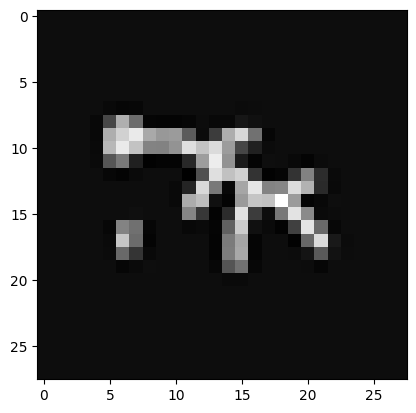

In [54]:
plt.imshow(image[0], cmap = 'gray')

In [55]:
pred = classes[model(image.reshape(1,1,28,28)).argmax(1).item()]

'ant'